In [6]:
# Real-world modules
from src.real_world.preprocess_real import prepare_real_dataset
from src.real_world.train_lr_real import train_lr_real, evaluate_lr_real
from src.real_world.train_mlp_real import train_mlp_real

# Standard libraries
import pandas as pd
import numpy as np


In [7]:
# Load data
df = pd.read_csv("diabetes_dataset.csv")

data = prepare_real_dataset(df)

X_train = data["X_train"]
X_val   = data["X_val"]
X_test  = data["X_test"]

y_train = data["y_train"]
y_val   = data["y_val"]
y_test  = data["y_test"]

sens_val  = data["sens_val"]
sens_test = data["sens_test"]


print("Train shape:", X_train.shape)
print("Val shape:  ", X_val.shape)
print("Test shape: ", X_test.shape)

print("\nSensitive attribute counts (TEST SET):")
print(sens_test["gender"].value_counts())
print(sens_test["race"].value_counts())



Train shape: (55989, 11)
Val shape:   (13998, 11)
Test shape:  (29995, 11)

Sensitive attribute counts (TEST SET):
gender
Female    17543
Male      12452
Name: count, dtype: int64
race
AfricanAmerican    6113
Caucasian          6060
Asian              6004
Hispanic           5933
Other              5885
Name: count, dtype: int64


In [4]:
X_train.shape

(55989, 11)

In [5]:
df.head()


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes,race
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif...",Other
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.,Asian
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ...",Other
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif...",Caucasian
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ...",AfricanAmerican


In [6]:
# -----------------------------
# Train logistic regression
# -----------------------------
lr_model = train_lr_real(X_train, y_train)

# -----------------------------
# Predict risk scores on test set
# -----------------------------
lr_results = evaluate_lr_real(lr_model, X_test)

# -----------------------------
# Predicted probabilities (risk scores)
# -----------------------------
y_pred_probs_lr = lr_results["y_pred_probs"]


Epoch 1/50 | Train Loss: 0.1444 | Val Loss: 0.1199
Epoch 2/50 | Train Loss: 0.1065 | Val Loss: 0.1036
Epoch 3/50 | Train Loss: 0.0975 | Val Loss: 0.0959
Epoch 4/50 | Train Loss: 0.0914 | Val Loss: 0.0918
Epoch 5/50 | Train Loss: 0.0879 | Val Loss: 0.0879
Epoch 6/50 | Train Loss: 0.0858 | Val Loss: 0.0861
Epoch 7/50 | Train Loss: 0.0844 | Val Loss: 0.0855
Epoch 8/50 | Train Loss: 0.0834 | Val Loss: 0.0844
Epoch 9/50 | Train Loss: 0.0828 | Val Loss: 0.0853
Epoch 10/50 | Train Loss: 0.0823 | Val Loss: 0.0840
Epoch 11/50 | Train Loss: 0.0816 | Val Loss: 0.0834
Epoch 12/50 | Train Loss: 0.0814 | Val Loss: 0.0832
Epoch 13/50 | Train Loss: 0.0812 | Val Loss: 0.0830
Epoch 14/50 | Train Loss: 0.0809 | Val Loss: 0.0839
Epoch 15/50 | Train Loss: 0.0806 | Val Loss: 0.0839
Epoch 16/50 | Train Loss: 0.0805 | Val Loss: 0.0848
Epoch 17/50 | Train Loss: 0.0806 | Val Loss: 0.0835
Epoch 18/50 | Train Loss: 0.0803 | Val Loss: 0.0826
Epoch 19/50 | Train Loss: 0.0802 | Val Loss: 0.0822
Epoch 20/50 | Train L

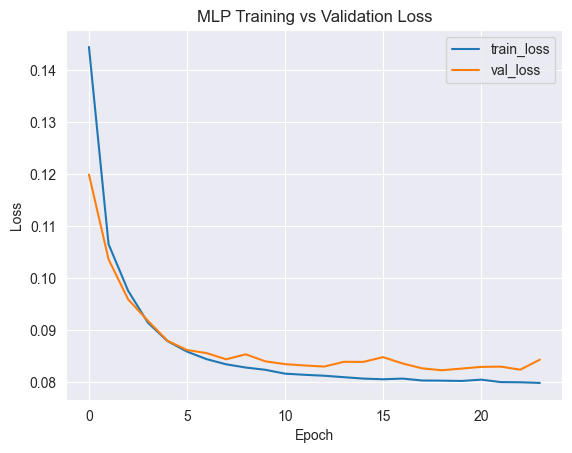

In [8]:

nn_results = train_mlp_real(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    input_dim=X_train.shape[1],
    n_epochs=50,
    lr=0.001,
    patience=5,
    plot_training=True
)

y_pred_probs_nn = nn_results["y_pred_probs"]


In [71]:
thresholds = [0.2, 0.3, 0.5, 0.7]

print("Threshold | TPR | FPR (NN)")
for t in thresholds:
    # True positives
    tpr = (y_pred_probs_nn[y_true == 1] >= t).mean()

    # False positives
    fpr = (y_pred_probs_nn[y_true == 0] >= t).mean()

    print(f"{t:>9} | {tpr:.2f} | {fpr:.2f}")

print("Threshold | TPR | FPR (LR)")
for t in thresholds:
    # True positives
    tpr = (y_pred_probs_lr[y_true == 1] >= t).mean()

    # False positives
    fpr = (y_pred_probs_l[y_true == 0] >= t).mean()

    print(f"{t:>9} | {tpr:.2f} | {fpr:.2f}")


Threshold | TPR | FPR (NN)
      0.2 | 0.80 | 0.04
      0.3 | 0.73 | 0.01
      0.5 | 0.67 | 0.00
      0.7 | 0.67 | 0.00
Threshold | TPR | FPR (LR)
      0.2 | 0.76 | 0.05
      0.3 | 0.71 | 0.03
      0.5 | 0.63 | 0.01
      0.7 | 0.53 | 0.00


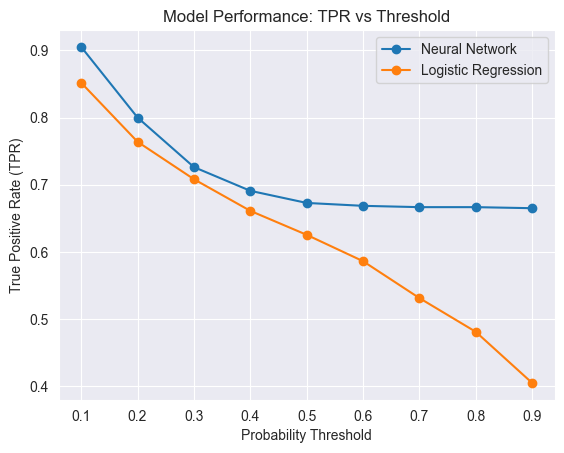

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Performance plot: TPR vs threshold
# -----------------------------
thresholds = np.linspace(0.1, 0.9, 9)

tpr_nn = []
tpr_lr = []

for t in thresholds:
    tpr_nn.append((y_pred_probs_nn[y_true == 1] >= t).mean())
    tpr_lr.append((y_pred_probs_lr[y_true == 1] >= t).mean())

plt.figure()
plt.plot(thresholds, tpr_nn, marker='o', label="Neural Network")
plt.plot(thresholds, tpr_lr, marker='o', label="Logistic Regression")
plt.xlabel("Probability Threshold")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Model Performance: TPR vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


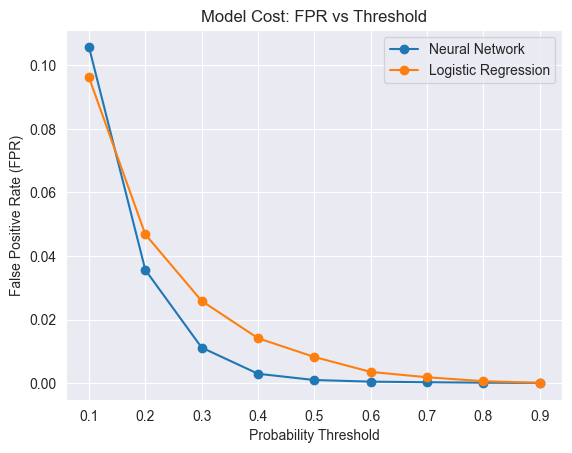

In [78]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Performance plot: FPR vs threshold
# -----------------------------
thresholds = np.linspace(0.1, 0.9, 9)

fpr_nn = []
fpr_lr = []

for t in thresholds:
    # Healthy individuals are y_true == 0
    fpr_nn.append((y_pred_probs_nn[y_true == 0] >= t).mean())
    fpr_lr.append((y_pred_probs_lr[y_true == 0] >= t).mean())

plt.figure()
plt.plot(thresholds, fpr_nn, marker='o', label="Neural Network")
plt.plot(thresholds, fpr_lr, marker='o', label="Logistic Regression")
plt.xlabel("Probability Threshold")
plt.ylabel("False Positive Rate (FPR)")
plt.title("Model Cost: FPR vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [44]:
def tpr_by_group(y_true, y_pred_probs, groups, threshold=0.5):
    """
    Computes True Positive Rate (TPR) per group.

    y_true: true labels (0 or 1)
    y_pred_probs: predicted probabilities from the model
    groups: demographic group labels
    threshold: probability cutoff
    """
    results = {}

    for g in groups.unique():
        idx = (groups == g)
        y_true_g = y_true[idx]
        y_pred_probs_g = y_pred_probs[idx]

        positives = y_true_g == 1

        if positives.sum() == 0:
            results[g] = np.nan
        else:
            tpr = (y_pred_probs_g[positives] >= threshold).mean()
            results[g] = tpr

    return results


In [65]:
threshold = 0.2

tpr_gender_nn = tpr_by_group(
    y_true=y_true,
    y_pred_probs=y_pred_probs_nn,
    groups=sens_test["gender"],
    threshold=threshold
)

print("NN TPR by gender:", tpr_gender_nn)


NN TPR by gender: {'Female': np.float64(0.8066001534919417), 'Male': np.float64(0.7931034482758621)}


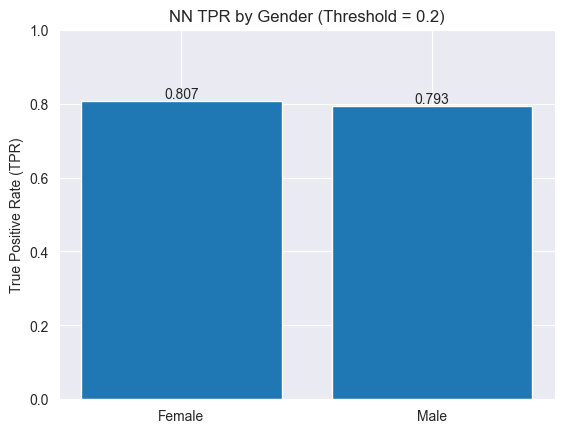

In [49]:
# TPR values
groups = ["Female", "Male"]
tpr_values = [0.8066001534919417, 0.7931034482758621]

# Create bar plot
plt.figure()
bars = plt.bar(groups, tpr_values)
plt.ylim(0, 1)
plt.ylabel("True Positive Rate (TPR)")
plt.title("NN TPR by Gender (Threshold = 0.2)")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()


In [66]:
threshold = 0.2

tpr_race_nn = tpr_by_group(
    y_true=y_true,
    y_pred_probs=y_pred_probs_nn,
    groups=sens_test["race"],
    threshold=threshold
)

print("NN TPR by race:", tpr_race_nn)


NN TPR by race: {'AfricanAmerican': np.float64(0.7855855855855856), 'Asian': np.float64(0.8035363457760314), 'Other': np.float64(0.8064516129032258), 'Caucasian': np.float64(0.7903846153846154), 'Hispanic': np.float64(0.8163672654690619)}


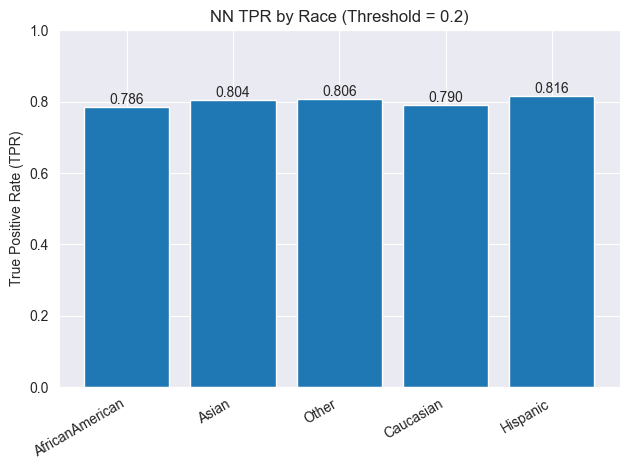

In [51]:
import matplotlib.pyplot as plt

# Dictionary from your output
tpr_race_nn = {
    "AfricanAmerican": 0.7855855855855856,
    "Asian": 0.8035363457760314,
    "Other": 0.8064516129032258,
    "Caucasian": 0.7903846153846154,
    "Hispanic": 0.8163672654690619
}

groups = list(tpr_race_nn.keys())
tpr_values = list(tpr_race_nn.values())

# Create bar plot
plt.figure()
bars = plt.bar(groups, tpr_values)
plt.ylim(0, 1)
plt.ylabel("True Positive Rate (TPR)")
plt.title("NN TPR by Race (Threshold = 0.2)")
plt.xticks(rotation=30, ha="right")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [67]:
threshold = 0.2

tpr_race_lr = tpr_by_group(
    y_true=y_true,
    y_pred_probs=y_pred_probs_lr,
    groups=sens_test["race"],
    threshold=threshold
)

print("LR TPR by race:", tpr_race_lr)


LR TPR by race: {'AfricanAmerican': np.float64(0.7477477477477478), 'Asian': np.float64(0.762278978388998), 'Other': np.float64(0.7763440860215054), 'Caucasian': np.float64(0.7615384615384615), 'Hispanic': np.float64(0.7744510978043913)}


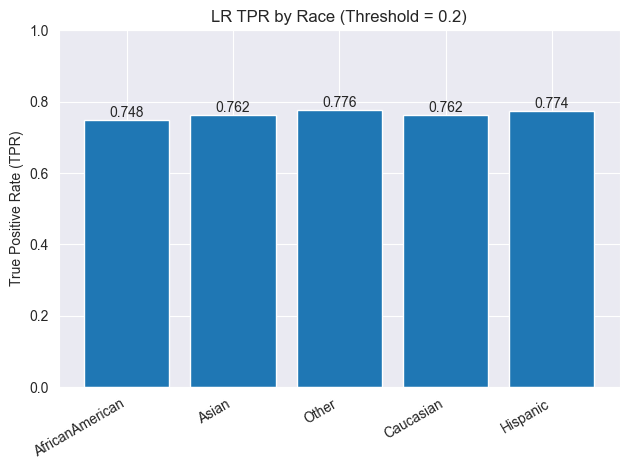

In [68]:
tpr_race_lr = {
    "AfricanAmerican": 0.7477477477477478,
    "Asian": 0.762278978388998,
    "Other": 0.7763440860215054,
    "Caucasian": 0.7615384615384615,
    "Hispanic": 0.7744510978043913
}

groups = list(tpr_race_lr.keys())
tpr_values = list(tpr_race_lr.values())

# Create bar plot
plt.figure()
bars = plt.bar(groups, tpr_values)
plt.ylim(0, 1)
plt.ylabel("True Positive Rate (TPR)")
plt.title("LR TPR by Race (Threshold = 0.2)")
plt.xticks(rotation=30, ha="right")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


In [69]:
threshold = 0.2

tpr_gender_lr = tpr_by_group(
    y_true=y_true,
    y_pred_probs=y_pred_probs_lr,
    groups=sens_test["gender"],
    threshold=threshold
)

print("LR TPR by gender:", tpr_gender_lr)


LR TPR by gender: {'Female': np.float64(0.7636224098234843), 'Male': np.float64(0.764234161988773)}


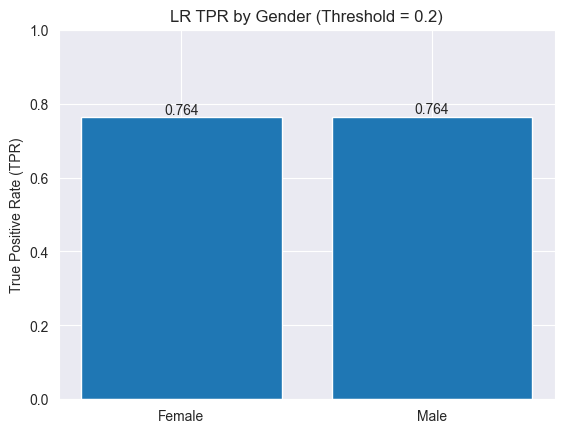

In [70]:
import matplotlib.pyplot as plt

# LR TPR values by gender
tpr_gender_lr = {
    "Female": 0.7636224098234843,
    "Male": 0.764234161988773
}

groups = list(tpr_gender_lr.keys())
tpr_values = list(tpr_gender_lr.values())

# Create bar plot
plt.figure()
bars = plt.bar(groups, tpr_values)
plt.ylim(0, 1)
plt.ylabel("True Positive Rate (TPR)")
plt.title("LR TPR by Gender (Threshold = 0.2)")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()
